In [1]:
import pandas as pd
df=pd.read_csv("DataCoSupplyChainDataset.csv",encoding='ISO-8859-1')

In [2]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [3]:
# Display the first few rows to verify the data load
print("=== First 5 Rows of Supply Chain Dataset ===")
print(df.head())

=== First 5 Rows of Supply Chain Dataset ===
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1  

In [4]:
print("\n=== Missing Values Count ===")
missing_values = df.isnull().sum()
print(missing_values)


=== Missing Values Count ===
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market    

In [5]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')
            
features_with_missing_values(df)

Percentage of Total Missing Values is  3.51 %
Missing Value Estimation :
The Feature  Customer Lname  has 8 missing values
The Feature  Customer Zipcode  has 3 missing values
The Feature  Order Zipcode  has 155679 missing values
The Feature  Product Description  has 180519 missing values


In [6]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

Dataset rows: 180519
Dataset columns: 53


In [7]:
modeling_columns = ['Type',
                  'Days for shipping (real)', 
                  'Days for shipment (scheduled)',
                  'Benefit per order',
                  'Sales per customer',
                  'Latitude',
                  'Longitude',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Total',
                  'Order Profit Per Order',
                  'Order Status',
                  'Shipping Mode',
                  'Late_delivery_risk']

In [8]:
len(modeling_columns)

14

In [10]:
def drop_columns(dataset, columns_to_drop):
    dataset = dataset.drop(columns=columns_to_drop)
    print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(dataset.columns)}")
    return dataset

In [11]:
columns_to_drop = [col for col in df.columns if col not in modeling_columns]

In [12]:
len(columns_to_drop)

39

In [13]:
df1=drop_columns(df,columns_to_drop)

39 columns dropped successfully. Number of columns remaining: 14


In [14]:
print(f"Dataset rows: {df1.shape[0]}")
print(f"Dataset columns: {df1.shape[1]}")

Dataset rows: 180519
Dataset columns: 14


In [15]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [16]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Total',
       'Order Profit Per Order', 'Order Status', 'Shipping Mode'],
      dtype='object')

In [17]:
# check null values
df1.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
Latitude                         0
Longitude                        0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Total                 0
Order Profit Per Order           0
Order Status                     0
Shipping Mode                    0
dtype: int64

In [18]:
#analyze categorical columns 
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Order Status
Number of unique values: 9

Column: Shipping Mode
Number of unique values: 4


In [19]:
df1.duplicated().sum()

4

In [20]:
df1[df1.duplicated()]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
94789,DEBIT,5,4,53.230000,118.290001,1,28.102118,-82.512115,11.7,0.09,118.290001,53.230000,COMPLETE,Standard Class
137818,PAYMENT,2,4,138.589996,395.980011,0,21.287289,-157.671402,4.0,0.01,395.980011,138.589996,PENDING_PAYMENT,Standard Class
146875,DEBIT,2,2,93.599998,359.980011,0,29.780575,-95.171997,40.0,0.10,359.980011,93.599998,COMPLETE,Second Class
175279,DEBIT,2,1,120.949997,335.980011,1,18.380119,-66.183128,64.0,0.16,335.980011,120.949997,COMPLETE,First Class


In [21]:
df1=df1.drop_duplicates()

In [22]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [23]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Type','Order Status', 'Shipping Mode']
le = LabelEncoder()
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])

C:\Users\cstd\AppData\Local\Temp\ipykernel_14976\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = le.fit_transform(df1[col])
C:\Users\cstd\AppData\Local\Temp\ipykernel_14976\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = le.fit_transform(df1[col])
C:\Users\cstd\AppData\Local\Temp\ipykernel_14976\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

In [24]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [25]:
X = df1.drop(columns=['Late_delivery_risk'])  # features
y = df1['Late_delivery_risk']                 # target

In [26]:
X

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [27]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 180515, dtype: int64

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
X_scaled

array([[0.33333333, 0.5       , 1.        , ..., 0.84179973, 0.25      ,
        1.        ],
       [1.        , 0.83333333, 1.        , ..., 0.77618291, 0.625     ,
        1.        ],
       [0.        , 0.66666667, 1.        , ..., 0.77643548, 0.125     ,
        1.        ],
       ...,
       [1.        , 0.83333333, 1.        , ..., 0.85141263, 0.625     ,
        1.        ],
       [0.66666667, 0.5       , 1.        , ..., 0.86011167, 0.75      ,
        1.        ],
       [0.66666667, 0.66666667, 1.        , ..., 0.85678012, 0.75      ,
        1.        ]])

In [30]:
X_scaled.shape

(180515, 13)

In [31]:
import numpy as np
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [32]:
X_lstm.shape 

(180515, 1, 13)

In [33]:
X.shape[1]

13

In [34]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Bidirectional, LSTM ,Dense


def feature_extraction(input_shape):
    inputs=Input(shape=input_shape)
    x=LSTM(64,return_sequences=True)(inputs)
    x=Dense(64,activation='relu')(x)
    x=Dense(32,activation='relu')(x)
    model=Model(inputs=inputs,outputs=x)
    return model


In [35]:
input_shape = (1, X.shape[1])
model=feature_extraction(input_shape)

In [36]:
model

In [37]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [38]:
X_features = model.predict(X_lstm)
print(X_features.shape) 

5642/5642 [==============================] - 10s 2ms/step
(180515, 1, 32)


In [39]:
X_features

array([[[0.        , 0.00137231, 0.        , ..., 0.        ,
         0.005705  , 0.02464279]],

       [[0.        , 0.02446634, 0.        , ..., 0.        ,
         0.02134046, 0.00571922]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.00333199, 0.03139286]],

       ...,

       [[0.        , 0.02500036, 0.        , ..., 0.        ,
         0.01505418, 0.0176247 ]],

       [[0.        , 0.01690301, 0.        , ..., 0.        ,
         0.01323386, 0.02220646]],

       [[0.        , 0.02068861, 0.        , ..., 0.        ,
         0.01507764, 0.02031237]]], dtype=float32)

In [40]:
y.shape

(180515,)

In [ ]:
#np.save("simple_LSTM_64_32",X_features)

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_remaining ,y_train ,y_remaining=train_test_split(X_features,y,test_size=0.4,random_state=42)

#spliting the remaining data into testing and validation 

X_val,X_test,y_val,y_test=train_test_split(X_remaining ,y_remaining , test_size=0.5,random_state=42)

In [43]:
X_train.shape, X_val.shape ,X_test.shape , y_train.shape, y_val.shape ,y_test.shape 

((108309, 1, 32),
 (36103, 1, 32),
 (36103, 1, 32),
 (108309,),
 (36103,),
 (36103,))

In [44]:
X_train=X_train.reshape(X_train.shape[0],-1)
X_test=X_test.reshape(X_test.shape[0],-1)
X_val=X_val.reshape(X_val.shape[0],-1)

In [45]:
X_train.shape, X_test.shape,X_val.shape

((108309, 32), (36103, 32), (36103, 32))

In [46]:
#softmax regression

In [47]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
softmax_model=LogisticRegression(max_iter=1000 , multi_class='multinomial')
softmax_model.fit(X_train , y_train)

C:\Users\cstd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [48]:
y_pred=softmax_model.predict(X_test)

In [49]:
y_pred

array([0, 1, 1, ..., 0, 1, 1], dtype=int64)

In [50]:
accuracy=accuracy_score(y_test,y_pred)
print("testing accuracy:",accuracy*100)

testing accuracy: 91.43007506301414


In [51]:
y_pred_training=softmax_model.predict(X_train)

In [52]:
y_pred_training

array([1, 0, 1, ..., 0, 1, 0], dtype=int64)

In [53]:
accuracy=accuracy_score(y_train,y_pred_training)
print("training accuracy:",accuracy*100)

training accuracy: 91.61011550286679


In [54]:
y_pred_val=softmax_model.predict(X_val)

In [55]:
y_pred_val

array([1, 0, 1, ..., 1, 0, 0], dtype=int64)

In [56]:
val_accuracy=accuracy_score(y_val,y_pred_val)
print("validation accuracy:",val_accuracy*100)

validation accuracy: 91.46331329806388


In [57]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90     16393
           1       0.91      0.94      0.92     19710

    accuracy                           0.91     36103
   macro avg       0.92      0.91      0.91     36103
weighted avg       0.91      0.91      0.91     36103



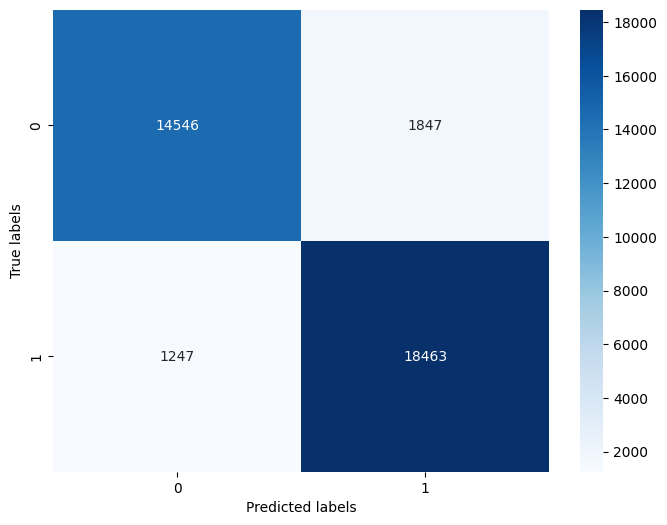

In [58]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

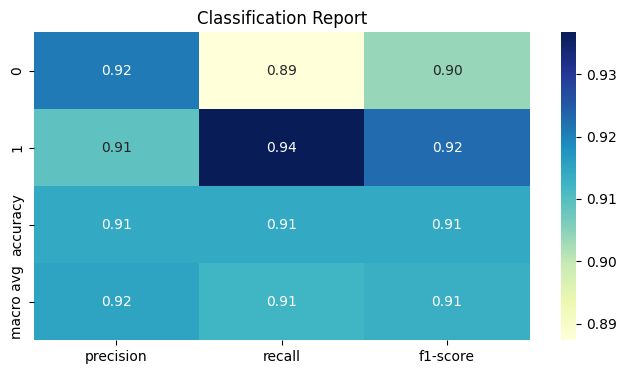

In [59]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

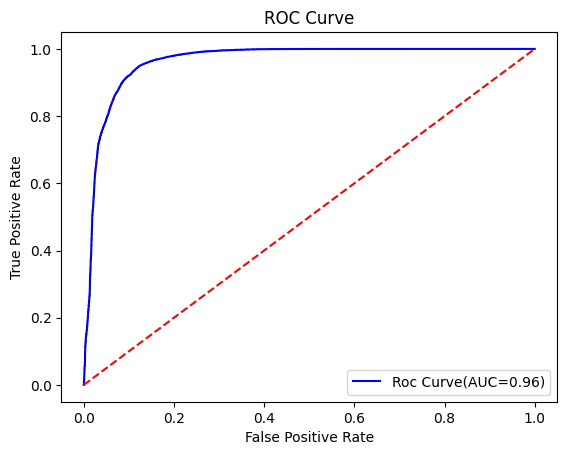

AUC Score: 0.9641274661447823


In [60]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=softmax_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [61]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [62]:
tn,fp,fn,tp=cm.ravel()

In [63]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [64]:
tn,fp,fn,tp

(14546, 1847, 1247, 18463)

In [65]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.8270760526076582,
 0.826608364391733,
 0.9090595765632693,
 0.9367326230339929,
 0.922688655672164,
 0.11267004209113646,
 0.06326737696600711)

In [66]:
#rf

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # features_train from LSTM on training set

# Predict on test features
y_pred = rf.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 0.9973963382544387


In [68]:
y_pred_train = rf.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 1.0


In [69]:
y_pred_val = rf.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 0.9972301470791901


In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16393
           1       1.00      1.00      1.00     19710

    accuracy                           1.00     36103
   macro avg       1.00      1.00      1.00     36103
weighted avg       1.00      1.00      1.00     36103



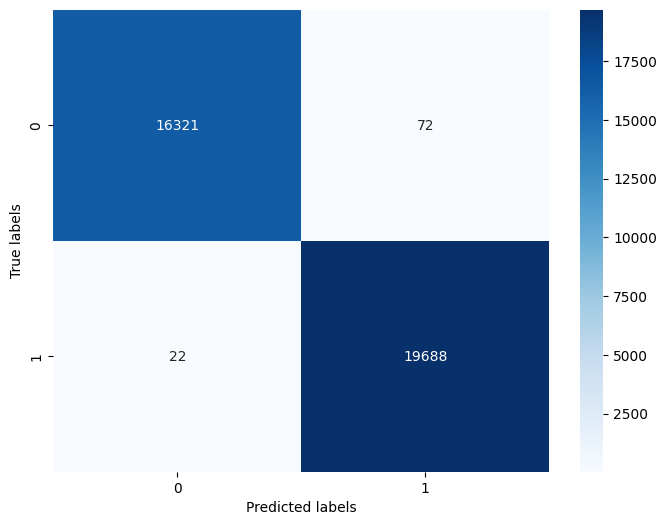

In [72]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

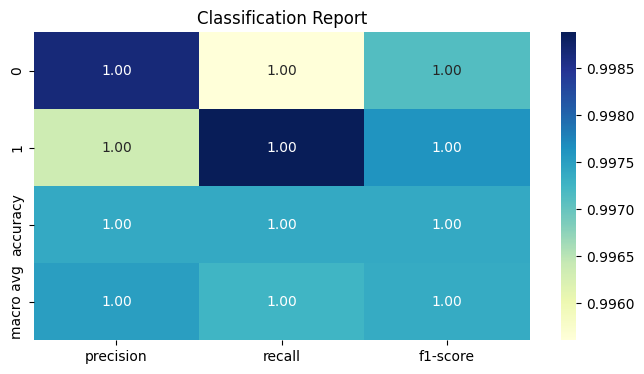

In [73]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [74]:
X_fe=X_features.reshape(X_features.shape[0],-1)

In [75]:
X_fe.shape ,y.shape 

((180515, 32), (180515,))

In [76]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    rf.fit(X_tr,y_tr)
    y_pred=rf.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')



Fold1:Accuracy=0.9985
Fold2:Accuracy=0.9981
Fold3:Accuracy=0.9980
Fold4:Accuracy=0.9981
Fold5:Accuracy=0.9975
Average Accuracy:0.9980


In [77]:
#After Five Folding cross validation
y_pred_train = rf.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9991505784376183


In [78]:
y_pred = rf.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [79]:
y_pred_val = rf.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


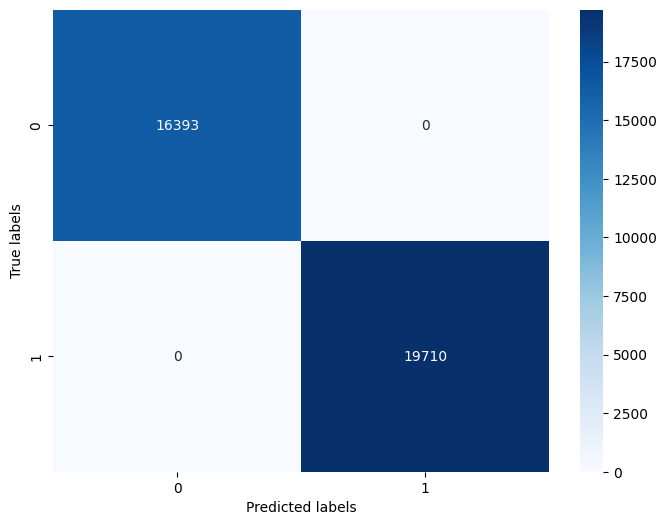

In [80]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

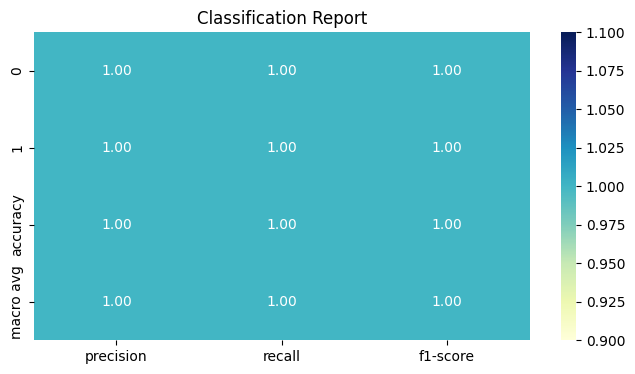

In [81]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

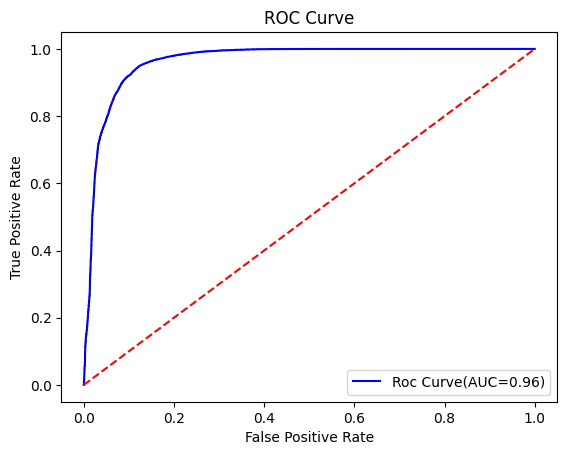

AUC Score: 0.9641274661447823


In [82]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=softmax_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [83]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [84]:
tn,fp,fn,tp=cm.ravel()

In [85]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [86]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [87]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [88]:
#svm

In [89]:
from sklearn.svm import SVC
svm_model=SVC(kernel='rbf', random_state=42,probability=True)
svm_model.fit(X_train,y_train)

SVC(probability=True, random_state=42)

In [90]:
y_pred=svm_model.predict(X_test)

In [91]:
y_pred

array([0, 1, 1, ..., 0, 1, 0], dtype=int64)

In [92]:
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9849596986400022


In [93]:
y_pred_train=svm_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9859660785345632


In [94]:
y_pred_val=svm_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9862615295127829


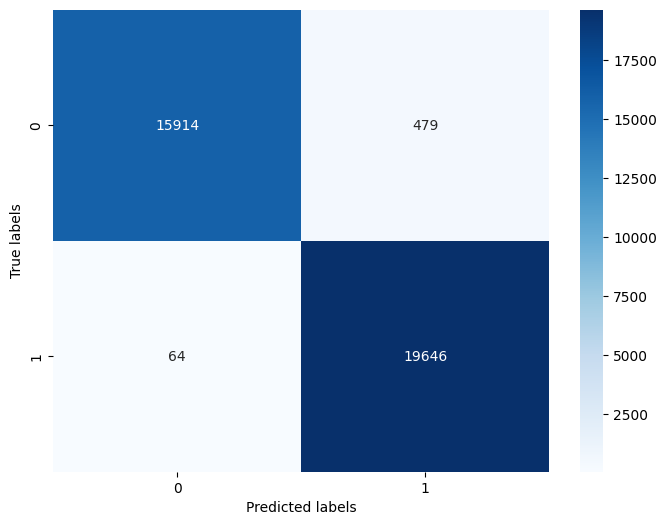

In [95]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

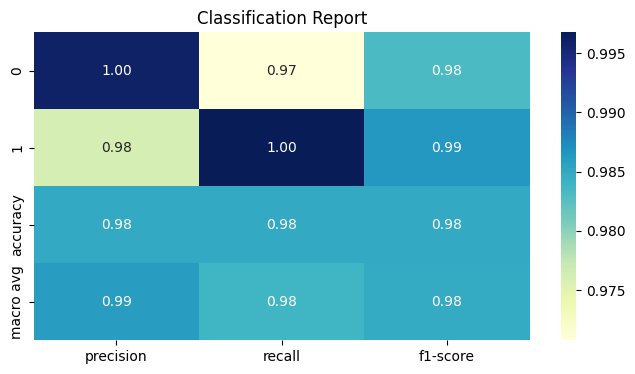

In [96]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

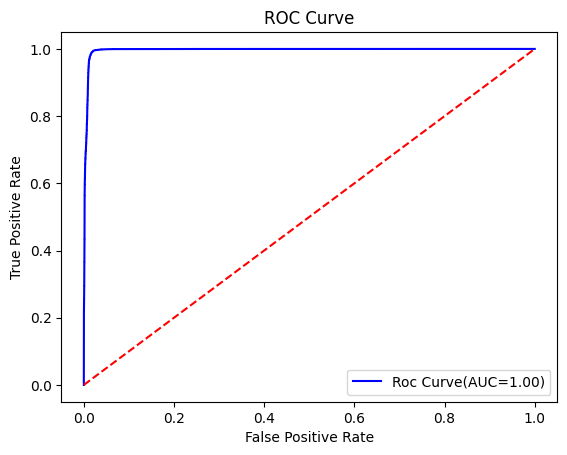

AUC Score: 0.9963712531146509


In [97]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=svm_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [98]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [99]:
tn,fp,fn,tp=cm.ravel()

In [100]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [101]:
tn,fp,fn,tp

(15914, 479, 64, 19646)

In [102]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9698603903316259,
 0.9695985583175976,
 0.9761987577639751,
 0.9967529173008625,
 0.9863687711811221,
 0.029219788934301227,
 0.0032470826991374937)

In [103]:
#KNN

In [104]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [105]:
y_pred=knn_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9959283162064094


In [106]:
y_pred_train=knn_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9977010220757278


In [107]:
y_pred_val=knn_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9958175220895771


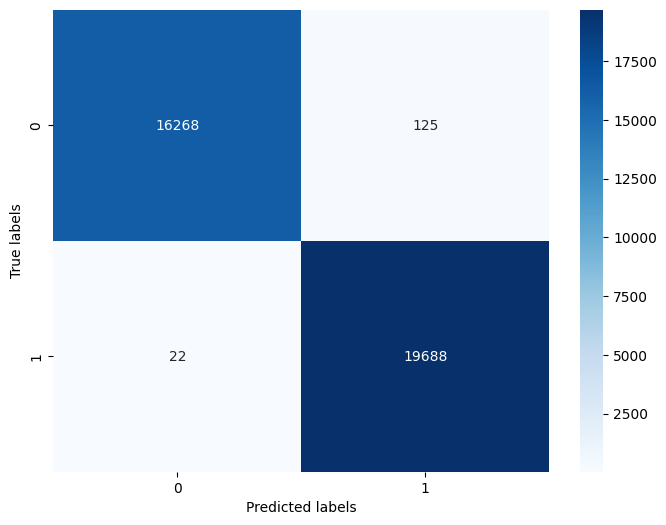

In [108]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

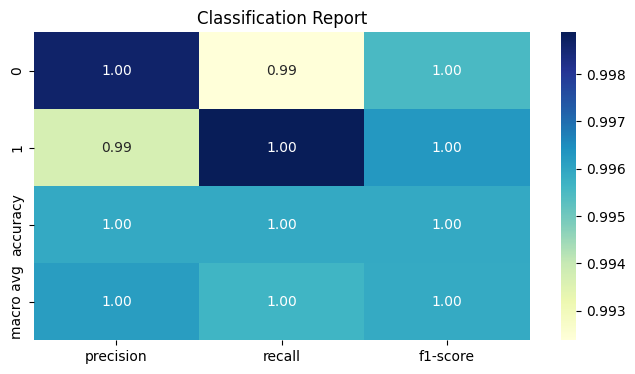

In [109]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

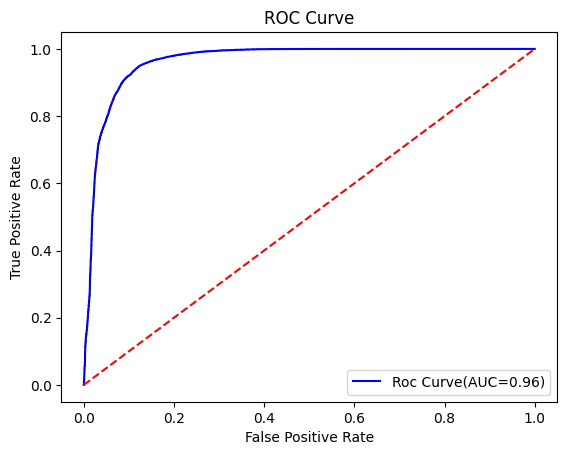

AUC Score: 0.9641274661447823


In [110]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=softmax_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [111]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [112]:
tn,fp,fn,tp=cm.ravel()

In [113]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [114]:
tn,fp,fn,tp

(16268, 125, 22, 19688)

In [115]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9917994017830655,
 0.9917829630742535,
 0.993691010952405,
 0.9988838153221715,
 0.9962806467120411,
 0.007625205880558775,
 0.0011161846778285135)

In [116]:
#Random trees

In [117]:
from sklearn.ensemble import ExtraTreesClassifier 

et_model=ExtraTreesClassifier(n_estimators=100,random_state=42)

In [118]:
et_model.fit(X_train,y_train)

ExtraTreesClassifier(random_state=42)

In [119]:
y_pred=et_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9980888014846412


In [120]:
y_pred_train=et_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 1.0


In [121]:
y_pred_val=et_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9981995956014735


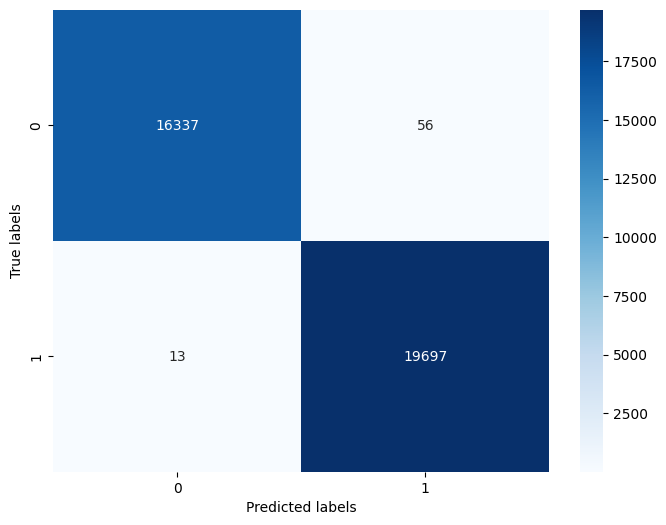

In [122]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

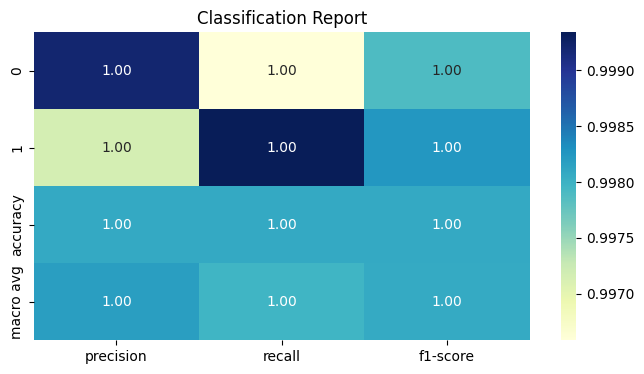

In [123]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [125]:
#5fold cross validation for et
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    et_model.fit(X_tr,y_tr)
    y_pred=et_model.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')



Fold1:Accuracy=0.9989
Fold2:Accuracy=0.9987
Fold3:Accuracy=0.9988
Fold4:Accuracy=0.9985
Fold5:Accuracy=0.9984
Average Accuracy:0.9987


In [126]:
#After Five Folding cross validation
y_pred_train = et_model.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9994737279450461


In [127]:
y_pred = et_model.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [128]:
y_pred_val = et_model.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


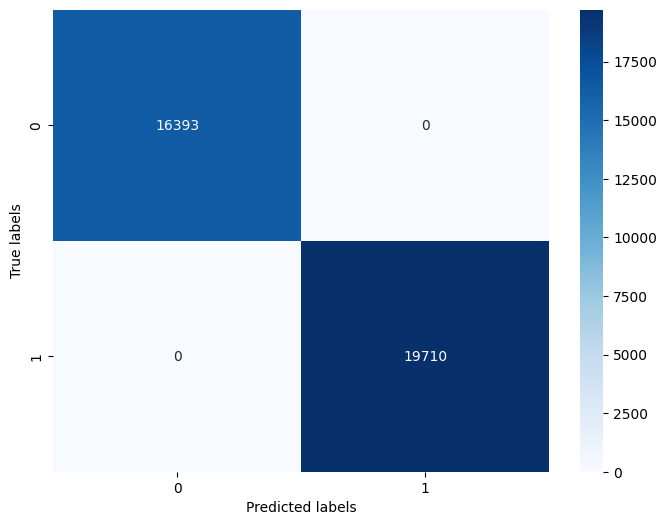

In [129]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

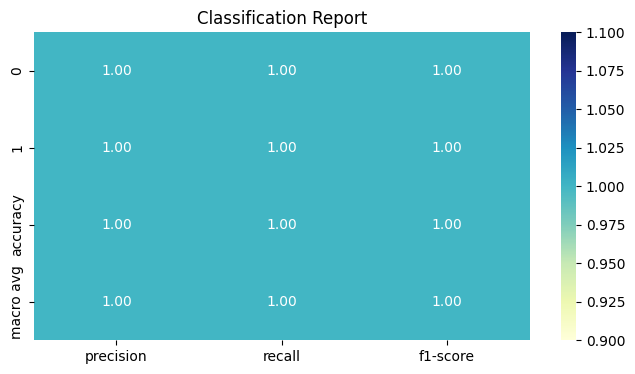

In [130]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

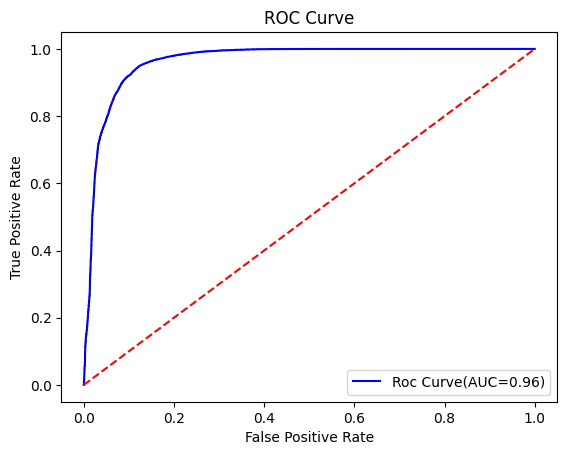

AUC Score: 0.9641274661447823


In [131]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=softmax_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [132]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [133]:
tn,fp,fn,tp=cm.ravel()

In [134]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [135]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [136]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [137]:
'''from sklearn.model_selection import GridSearchCV
param_grid={'n_estimators':[10,50,100],'max_depth':[None,5,10]}
grid_search=GridSearchCV(et_model,param_grid,cv=5)
grid_search.fit(X_train,y_train)
print("Best parameters:" ,grid_search.best_params_)
print("Best score:",grid_search.best_score_)

SyntaxError: EOF while scanning triple-quoted string literal (2669412713.py, line 6)

In [ ]:
'''best_model=grid_search.best_estimator_
best_model.fit(X_train,y_train)

ExtraTreesClassifier(random_state=42)

In [ ]:
'''y_pred_grid=best_model.predict(X_test)
print("Testing accuracy after grid search:",accuracy_score(y_test,y_pred_grid))

Testing accuracy after grid search: 0.9973963382544387


In [ ]:
'''y_pred_grid_train=best_model.predict(X_train)
print("Training accuracy after grid search:",accuracy_score(y_train,y_pred_grid_train))

Training accuracy after grid search: 1.0


In [138]:
#decision tree

In [139]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)

In [140]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [141]:
y_pred=dt_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9877849486192283


In [142]:
y_pred_train=dt_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 1.0


In [143]:
y_pred_val=dt_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9890036839043846


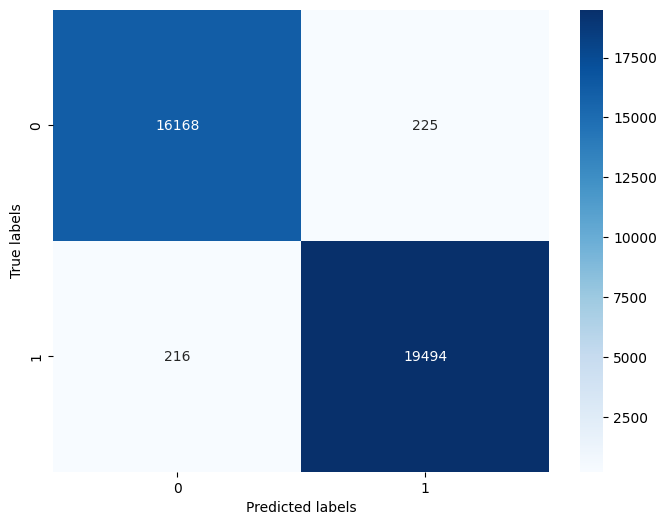

In [144]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

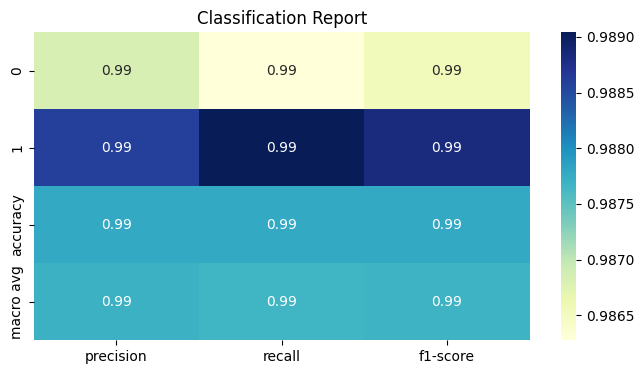

In [145]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [146]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    dt_model.fit(X_tr,y_tr)
    y_pred=dt_model.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')


Fold1:Accuracy=0.9907
Fold2:Accuracy=0.9904
Fold3:Accuracy=0.9913
Fold4:Accuracy=0.9917
Fold5:Accuracy=0.9919
Average Accuracy:0.9912


In [147]:
#After Five Folding cross validation
y_pred_train = dt_model.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9972855441376063


In [148]:
y_pred = dt_model.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [149]:
y_pred_val = dt_model.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


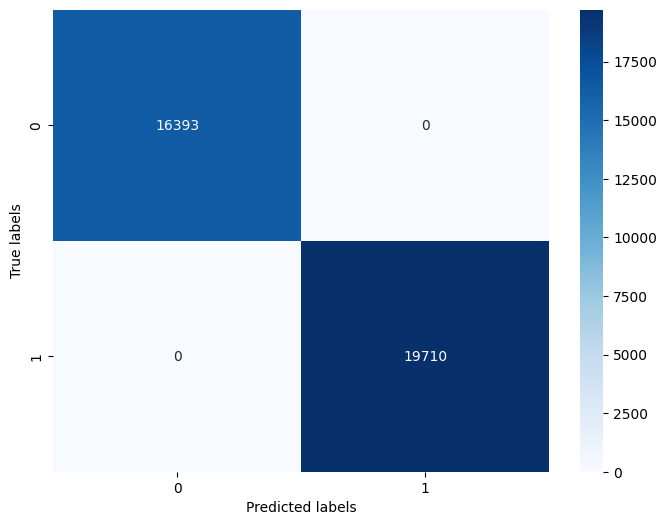

In [150]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

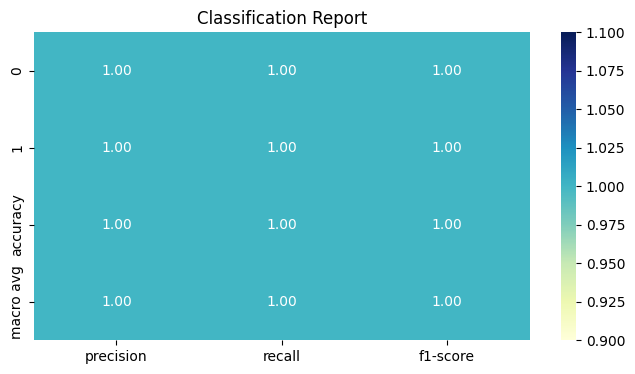

In [151]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

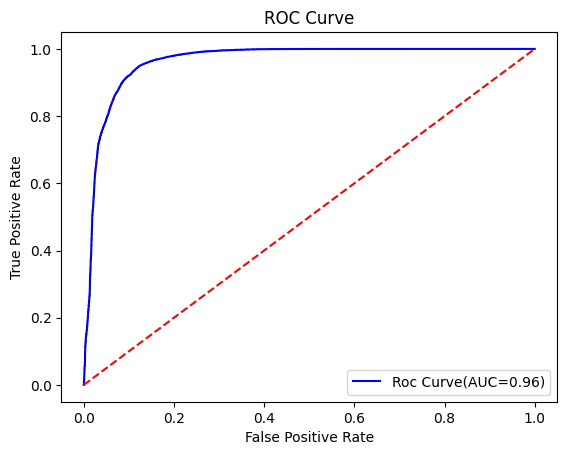

AUC Score: 0.9641274661447823


In [152]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=softmax_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [153]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [154]:
tn,fp,fn,tp=cm.ravel()

In [155]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [156]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [157]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [158]:
#mlp

In [159]:
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(hidden_layer_sizes=(50,50),max_iter=1000,random_state=42)

In [160]:
mlp.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)

In [161]:
y_pred=mlp.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9983657867767222


In [162]:
y_pred_train=mlp.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9988920588316761


In [163]:
y_pred_val=mlp.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9985596764811788


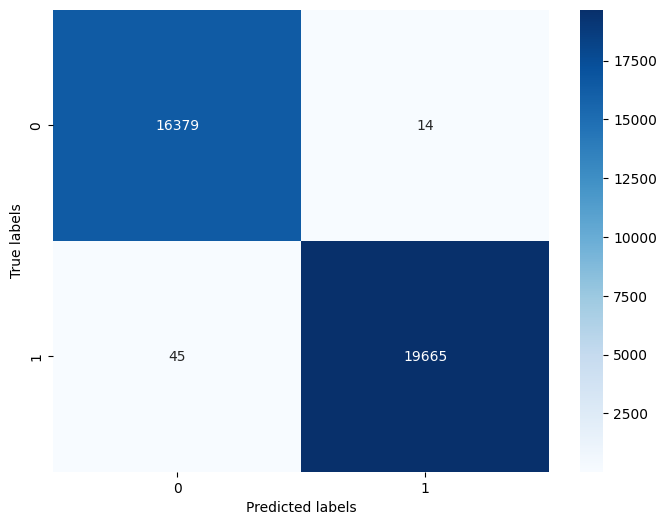

In [164]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

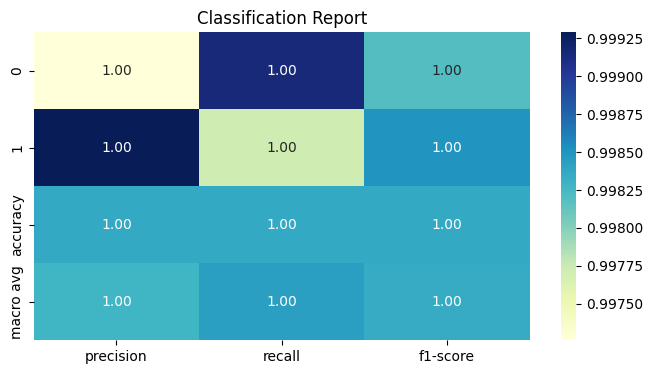

In [165]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

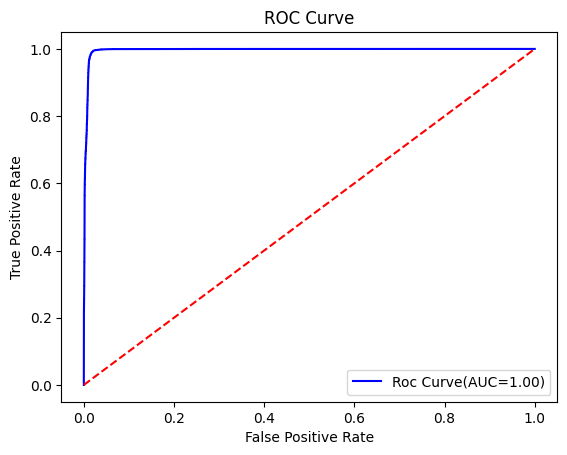

AUC Score: 0.9963712531146509


In [166]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=svm_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [167]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [168]:
tn,fp,fn,tp=cm.ravel()

In [169]:
tn,fp,fn,tp

(16379, 14, 45, 19665)

In [170]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [171]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9967057680281854,
 0.9967042736553893,
 0.9992885817368768,
 0.997716894977169,
 0.9985021198811851,
 0.0008540230586225828,
 0.00228310502283105)